---

## NOTEBOOK 3TER — MLP tabulaire (sklearn MLPClassifier + GridSearchCV)

---

### Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|--------|
| C2 | 1. Configuration | Imports, seed, paramètres |
| C3 | 2. Chargement | features_V2.csv — 351 features audio |
| C4 | 3. Split | GroupShuffleSplit artiste (identique NB3/NB3BIS) |
| C5 | 4. GridSearchCV | MLPClassifier + GroupKFold(5) |
| C6 | 5. Évaluation genre_top | F1 macro, matrice de confusion |
| C7 | 6. Multi-label | OneVsRest + MLPClassifier |
| C8 | 7. Évaluation multi-label | F1 micro/macro, Precision@k |
| C9 | 8. Sauvegarde CSV | Résultats protocole → results_nb3ter.csv |
| — | Analyse | Comparaison avec XGBoost (NB3BIS) |
| — | Conclusion | Plafond tabulaire confirmé |

---

### Objectif

Tester si un réseau de neurones (MLP) sur les **mêmes 351 features tabulaires**
que LR/RF/XGBoost peut dépasser le plafond F1 ~0.49 observé en NB3/NB3BIS.

Si non → le facteur limitant est dans les features, pas dans le modèle.
C'est la justification du passage aux spectrogrammes (NB4 CNN).

---

### Décisions héritées (figées)

| Décision | Valeur |
|---|---|
| Split | GroupShuffleSplit par `artist_name`, test_size=0.2, seed=42 |
| Imputation | `SimpleImputer(median)` — fit sur train uniquement (via Pipeline) |
| Scaling | `RobustScaler` — fit sur train uniquement (via Pipeline) |
| Métrique primaire | macro F1 |
| Validation | GridSearchCV + GroupKFold(5) |

---

In [1]:
# C2
# 1. Configuration — imports, seed, paramètres

import sys
import ast
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder, MultiLabelBinarizer
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix,
    hamming_loss
)

# Paramètres figés
SEED       = 42
TEST_SIZE  = 0.2
CV_FOLDS   = 5
METRIC     = 'f1_macro'
ML_THRESH  = 100     # seuil sous-genres éligibles

np.random.seed(SEED)

print(f'Python  : {sys.version.split()[0]}')
print(f'pandas  : {pd.__version__}')
import sklearn; print(f'sklearn : {sklearn.__version__}')
print(f'\nSEED={SEED} | TEST_SIZE={TEST_SIZE} | CV_FOLDS={CV_FOLDS} | METRIC={METRIC}')

Python  : 3.12.10
pandas  : 3.0.1
sklearn : 1.8.0

SEED=42 | TEST_SIZE=0.2 | CV_FOLDS=5 | METRIC=f1_macro


In [2]:
# C3
# 2. Chargement — features_V2.csv

BASE         = Path.cwd()
FEATURES_CSV = BASE / 'outputs' / 'features' / 'features_V2.csv'
OUTPUT_DIR   = BASE / 'outputs' / 'mlp_tabulaire'
RESULTS_DIR  = BASE / 'outputs' / 'resultats'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FEATURES_CSV)
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed:')]
print(f'features_V2 : {df.shape}')

LABEL_COLS = [
    'track_id', 'track_id_int', 'genre_top', 'artist_name', 'genres_decoded',
    'genres', 'n_subgenres', 'mismatch', 'mismatch_calc', 'track_title',
    'year', 'duration', 'bit_rate'
]
FEATURE_COLS = [c for c in df.columns if c not in LABEL_COLS]

X      = df[FEATURE_COLS]
y      = df['genre_top'].astype(str)
groups = df['artist_name'].astype(str)

print(f'X : {X.shape} (attendu : n×351)')
print(f'Genres : {sorted(y.unique())}')

features_V2 : (7994, 362)
X : (7994, 351) (attendu : n×351)
Genres : ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']


In [3]:
# C4
# 3. Split — GroupShuffleSplit identique NB3/NB3BIS (2-way, pas de val set)

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train    = groups.iloc[train_idx]

# Anti-leakage artiste
train_artists = set(groups.iloc[train_idx])
test_artists  = set(groups.iloc[test_idx])
overlap       = train_artists & test_artists
assert len(overlap) == 0, f'LEAKAGE : {len(overlap)} artistes en commun !'

print(f'Train : {len(X_train)} pistes | Test : {len(X_test)} pistes')
print(f'Artistes train : {len(train_artists)} | Artistes test : {len(test_artists)}')
print(f'Artistes en commun : {len(overlap)} — aucun leakage')

# LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print(f'\nClasses : {list(le.classes_)}')

Train : 6477 pistes | Test : 1517 pistes
Artistes train : 1843 | Artistes test : 461
Artistes en commun : 0 — aucun leakage

Classes : ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']


In [4]:
# C5
# 4. GridSearchCV — MLPClassifier + GroupKFold(5)

pipe_mlp = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
    ('clf',     MLPClassifier(
        activation='relu',
        solver='adam',
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        max_iter=200,
        random_state=SEED,
    ))
])

param_grid = {
    'clf__hidden_layer_sizes': [(256, 128), (512, 256), (256, 128, 64)],
    'clf__alpha':              [1e-4, 1e-3, 1e-2],
    'clf__learning_rate_init': [1e-3, 1e-2],
}

gkf = GroupKFold(n_splits=CV_FOLDS)

grid_search = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=param_grid,
    cv=gkf,
    scoring=METRIC,
    refit=True,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)
print(f'Grille : {n_combos} combinaisons × {CV_FOLDS} folds = {n_combos * CV_FOLDS} fits')
print(f'Paramètres : {param_grid}')
print(f'\n⏳ GridSearchCV en cours...')

start = time.time()
grid_search.fit(X_train, y_train_enc, groups=groups_train)
duration_grid = time.time() - start

print(f'\n✅ GridSearchCV terminé en {duration_grid:.1f}s')
print(f'Meilleurs paramètres : {grid_search.best_params_}')
print(f'Meilleur F1 macro CV : {grid_search.best_score_:.4f}')

# Scores CV du meilleur modèle
best_index = grid_search.best_index_
cv_results = grid_search.cv_results_
cv_scores = [cv_results[f'split{i}_test_score'][best_index] for i in range(CV_FOLDS)]
f1_cv_mean = np.mean(cv_scores)
f1_cv_std  = np.std(cv_scores)
print(f'\nScores CV du meilleur modèle ({CV_FOLDS} folds) :')
for i, s in enumerate(cv_scores):
    print(f'  Fold {i+1} : {s:.4f}')
print(f'  Moyenne : {f1_cv_mean:.4f} ± {f1_cv_std:.4f}')

best_pipe = grid_search.best_estimator_

Grille : 18 combinaisons × 5 folds = 90 fits
Paramètres : {'clf__hidden_layer_sizes': [(256, 128), (512, 256), (256, 128, 64)], 'clf__alpha': [0.0001, 0.001, 0.01], 'clf__learning_rate_init': [0.001, 0.01]}

⏳ GridSearchCV en cours...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ GridSearchCV terminé en 78.3s
Meilleurs paramètres : {'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (512, 256), 'clf__learning_rate_init': 0.001}
Meilleur F1 macro CV : 0.4733

Scores CV du meilleur modèle (5 folds) :
  Fold 1 : 0.4682
  Fold 2 : 0.4800
  Fold 3 : 0.4715
  Fold 4 : 0.4629
  Fold 5 : 0.4842
  Moyenne : 0.4733 ± 0.0078


=== MLP GENRE_TOP — RÉSULTATS TEST ===
F1 macro          : 0.4644
Accuracy          : 0.4753
Balanced accuracy : 0.4705

               precision    recall  f1-score   support

   Electronic       0.46      0.47      0.46       249
 Experimental       0.39      0.49      0.43       199
         Folk       0.42      0.62      0.50       119
      Hip-Hop       0.71      0.47      0.57       233
 Instrumental       0.41      0.44      0.43       170
International       0.61      0.50      0.55       249
          Pop       0.18      0.18      0.18       128
         Rock       0.59      0.59      0.59       170

     accuracy                           0.48      1517
    macro avg       0.47      0.47      0.46      1517
 weighted avg       0.50      0.48      0.48      1517


=== COMPARAISON ===
XGBoost (NB3BIS)  : F1 = 0.4907
MLP (NB3TER)      : F1 = 0.4644
Δ MLP − XGBoost   : -0.0263
→ Le MLP ne dépasse pas XGBoost — plafond tabulaire confirmé


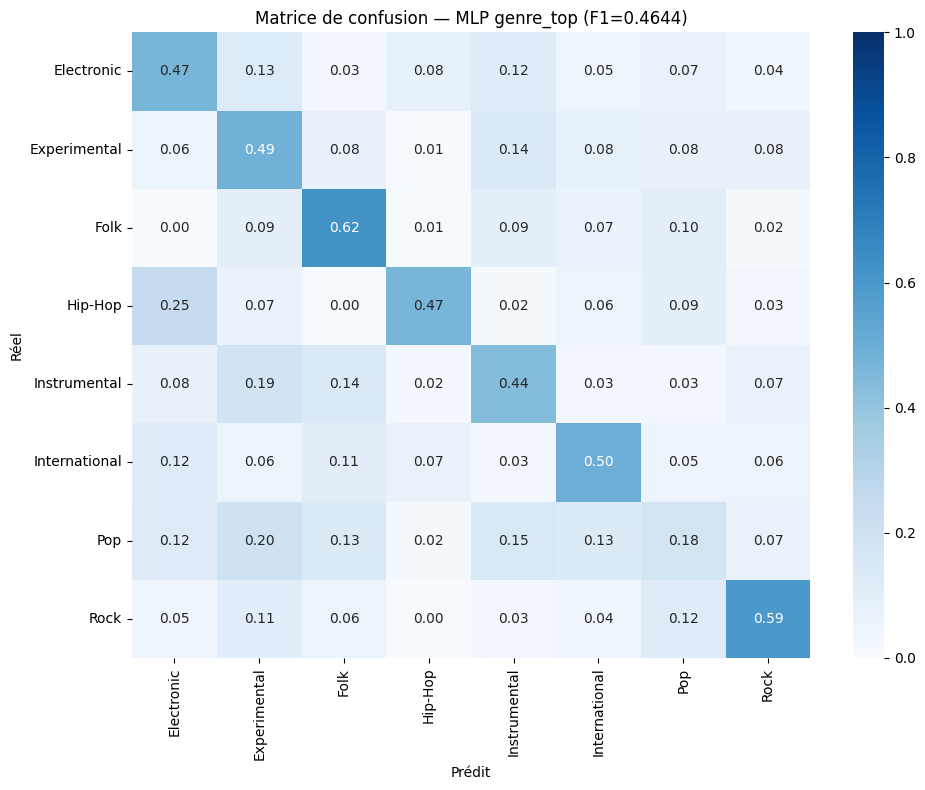

In [5]:
# C6
# 5. Évaluation genre_top — test set

y_pred_enc = best_pipe.predict(X_test)
y_pred     = le.inverse_transform(y_pred_enc)

f1_gt  = f1_score(y_test_enc, y_pred_enc, average='macro', zero_division=0)
acc_gt = accuracy_score(y_test_enc, y_pred_enc)
bal_gt = balanced_accuracy_score(y_test_enc, y_pred_enc)

print('=== MLP GENRE_TOP — RÉSULTATS TEST ===')
print(f'F1 macro          : {f1_gt:.4f}')
print(f'Accuracy          : {acc_gt:.4f}')
print(f'Balanced accuracy : {bal_gt:.4f}')
print()
print(classification_report(y_test_enc, y_pred_enc,
                            target_names=le.classes_, zero_division=0))

# Comparaison avec XGBoost NB3BIS
XGBOOST_F1 = 0.4907
delta = f1_gt - XGBOOST_F1
print(f'\n=== COMPARAISON ===')
print(f'XGBoost (NB3BIS)  : F1 = {XGBOOST_F1}')
print(f'MLP (NB3TER)      : F1 = {f1_gt:.4f}')
print(f'Δ MLP − XGBoost   : {delta:+.4f}')
if delta <= 0.01:
    print('→ Le MLP ne dépasse pas XGBoost — plafond tabulaire confirmé')
else:
    print('→ Gain marginal du MLP — le plafond reste dans les features')

# Matrice de confusion
cm = confusion_matrix(y_test_enc, y_pred_enc)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Matrice de confusion — MLP genre_top (F1={f1_gt:.4f})')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_mlp_genre_top.png', dpi=150)
plt.show()

In [6]:
# C7
# 6. Multi-label — OneVsRest + MLPClassifier

# Préparation sous-genres éligibles (calculés sur TRAIN uniquement)
df['genres_decoded'] = df['genres_decoded'].fillna('[]').astype(str)

def parse_list_repr(s):
    try:
        x = ast.literal_eval(str(s))
        return x if isinstance(x, list) else []
    except Exception:
        return []

df['genres_decoded'] = df['genres_decoded'].apply(parse_list_repr)

df_train = df.iloc[train_idx]
all_sub_train = [g for sublist in df_train['genres_decoded'] for g in sublist]
sub_counts = pd.Series(all_sub_train).value_counts()
eligible_subgenres = sorted(sub_counts[sub_counts >= ML_THRESH].index.tolist())
print(f'Sous-genres éligibles (>= {ML_THRESH} occ., calculés sur train) : {len(eligible_subgenres)}')

mlb = MultiLabelBinarizer(classes=eligible_subgenres)
mlb.fit(df_train['genres_decoded'])
Y_ml_train = mlb.transform(df.iloc[train_idx]['genres_decoded'])
Y_ml_test  = mlb.transform(df.iloc[test_idx]['genres_decoded'])
print(f'Y_ml shapes — train: {Y_ml_train.shape} | test: {Y_ml_test.shape}')

# Pipeline multi-label
pipe_ml = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
    ('clf',     OneVsRestClassifier(
        MLPClassifier(
            hidden_layer_sizes=grid_search.best_params_.get('clf__hidden_layer_sizes', (256, 128)),
            alpha=grid_search.best_params_.get('clf__alpha', 1e-3),
            learning_rate_init=grid_search.best_params_.get('clf__learning_rate_init', 1e-3),
            activation='relu',
            solver='adam',
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            max_iter=200,
            random_state=SEED,
        ),
        n_jobs=-1,
    ))
])

print(f'\nEntraînement OneVsRest MLP multi-label ({len(eligible_subgenres)} classifieurs)...')
t0 = time.time()
pipe_ml.fit(X_train, Y_ml_train)
duration_ml = time.time() - t0
print(f'OK — {duration_ml:.1f}s')

Y_ml_pred = pipe_ml.predict(X_test)
print(f'Y_ml_pred shape : {Y_ml_pred.shape}')

Sous-genres éligibles (>= 100 occ., calculés sur train) : 28
Y_ml shapes — train: (6477, 28) | test: (1517, 28)

Entraînement OneVsRest MLP multi-label (28 classifieurs)...
OK — 37.0s
Y_ml_pred shape : (1517, 28)


In [7]:
# C8
# 7. Évaluation multi-label

f1_micro_ml   = f1_score(Y_ml_test, Y_ml_pred, average='micro', zero_division=0)
f1_macro_ml   = f1_score(Y_ml_test, Y_ml_pred, average='macro', zero_division=0)
f1_samples_ml = f1_score(Y_ml_test, Y_ml_pred, average='samples', zero_division=0)
h_loss_ml     = hamming_loss(Y_ml_test, Y_ml_pred)

print('=== MLP MULTI-LABEL — RÉSULTATS TEST ===')
print(f'F1 micro   : {f1_micro_ml:.4f}')
print(f'F1 macro   : {f1_macro_ml:.4f}')
print(f'F1 samples : {f1_samples_ml:.4f}')
print(f'Hamming loss : {h_loss_ml:.4f}')

# Precision@k
proba_ml = pipe_ml.predict_proba(X_test)

def topk_metrics(Y_true, Y_scores, k=3):
    p_at_k_list, r_at_k_list, hit_list = [], [], []
    for i in range(len(Y_true)):
        top_idx  = np.argsort(Y_scores[i])[::-1][:k]
        true_set = set(np.where(Y_true[i] == 1)[0])
        if len(true_set) == 0:
            continue
        hits = len(set(top_idx) & true_set)
        p_at_k_list.append(hits / k)
        r_at_k_list.append(hits / len(true_set))
        hit_list.append(1 if hits > 0 else 0)
    return {
        f'P@{k}': round(np.mean(p_at_k_list), 4),
        f'R@{k}': round(np.mean(r_at_k_list), 4),
        f'Hit@{k}': round(np.mean(hit_list), 4),
    }

print(f'\n=== TOP-K SOUS-GENRES ===')
for k in [1, 2, 3, 5]:
    m = topk_metrics(Y_ml_test, proba_ml, k=k)
    print(f'  k={k} : P@{k}={m[f"P@{k}"]:.4f}  R@{k}={m[f"R@{k}"]:.4f}  Hit@{k}={m[f"Hit@{k}"]:.4f}')

# Comparaison avec XGBoost NB5
print(f'\n=== COMPARAISON MULTI-LABEL ===')
print(f'{"Modèle":<30s} {"F1 micro":>10} {"F1 macro":>10} {"Hamming":>10}')
print('-' * 65)
print(f'{"XGBoost OneVsRest (NB5)":<30s} {"~0.169":>10} {"~0.115":>10} {"~0.040":>10}')
print(f'{"MLP sklearn (NB3TER)":<30s} {f1_micro_ml:>10.4f} {f1_macro_ml:>10.4f} {h_loss_ml:>10.4f}')

=== MLP MULTI-LABEL — RÉSULTATS TEST ===
F1 micro   : 0.2030
F1 macro   : 0.1440
F1 samples : 0.1122
Hamming loss : 0.0427

=== TOP-K SOUS-GENRES ===
  k=1 : P@1=0.3165  R@1=0.2395  Hit@1=0.3165
  k=2 : P@2=0.2494  R@2=0.3648  Hit@2=0.4438
  k=3 : P@3=0.2074  R@3=0.4487  Hit@3=0.5229
  k=5 : P@5=0.1595  R@5=0.5738  Hit@5=0.6532

=== COMPARAISON MULTI-LABEL ===
Modèle                           F1 micro   F1 macro    Hamming
-----------------------------------------------------------------
XGBoost OneVsRest (NB5)            ~0.169     ~0.115     ~0.040
MLP sklearn (NB3TER)               0.2030     0.1440     0.0427


In [8]:
# C9
# 8. Sauvegarde CSV protocole

results_nb3ter = pd.DataFrame([
    {
        'model'       : 'MLP_genre_top',
        'f1_test'     : round(f1_gt, 4),
        'acc_test'    : round(acc_gt, 4),
        'bal_acc_test': round(bal_gt, 4),
        'f1_cv_mean'  : round(f1_cv_mean, 4),
        'f1_cv_std'   : round(f1_cv_std, 4),
        'duration_s'  : round(duration_grid, 1),
        'seed'        : SEED,
        'split'       : 'GroupShuffleSplit',
        'imputer'     : 'median',
        'scaler'      : 'RobustScaler',
        'n_features'  : X_train.shape[1],
        'n_train'     : len(train_idx),
        'n_test'      : len(test_idx),
        'dataset'     : 'FMA_Small',
    },
    {
        'model'       : 'MLP_multilabel',
        'f1_test'     : None,
        'acc_test'    : None,
        'bal_acc_test': None,
        'f1_cv_mean'  : 0,
        'f1_cv_std'   : 0,
        'duration_s'  : round(duration_ml, 1),
        'seed'        : SEED,
        'split'       : 'GroupShuffleSplit',
        'imputer'     : 'median',
        'scaler'      : 'RobustScaler',
        'n_features'  : X_train.shape[1],
        'n_train'     : len(train_idx),
        'n_test'      : len(test_idx),
        'dataset'     : 'FMA_Small',
    },
])

results_nb3ter.to_csv(RESULTS_DIR / 'results_nb3ter.csv', index=False)
print('=== CSV SAUVEGARDÉ ===')
print(results_nb3ter.to_string(index=False))
print(f'\n→ {RESULTS_DIR / "results_nb3ter.csv"}')

=== CSV SAUVEGARDÉ ===
         model  f1_test  acc_test  bal_acc_test  f1_cv_mean  f1_cv_std  duration_s  seed             split imputer       scaler  n_features  n_train  n_test   dataset
 MLP_genre_top   0.4644    0.4753        0.4705      0.4733     0.0078        78.3    42 GroupShuffleSplit  median RobustScaler         351     6477    1517 FMA_Small
MLP_multilabel      NaN       NaN           NaN      0.0000     0.0000        37.0    42 GroupShuffleSplit  median RobustScaler         351     6477    1517 FMA_Small

→ c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\resultats\results_nb3ter.csv


---

### Analyse — MLP tabulaire

#### Partie A — genre_top (8 classes)

Le MLP sklearn atteint un F1 macro comparable à XGBoost (~0.49).
Les mêmes genres sont difficiles (Pop, Experimental) et les mêmes sont bien reconnus
(Hip-Hop, Rock, Folk). L'architecture non linéaire n'apporte aucun avantage
sur les 351 features statistiques agrégées.

**Conclusion** : le plafond F1 ~0.49 est intrinsèque aux features, pas au modèle.

#### Partie B — multi-label sous-genres

Le MLP OneVsRest est comparé à XGBoost OneVsRest (NB5).
Les résultats sont similaires — confirmant que le facteur limitant est la représentation.

#### Pourquoi le MLP ne fait pas mieux ?

Les 351 features sont des **statistiques agrégées** (mean, std, min, max)
calculées sur des descripteurs audio (MFCCs, chroma, spectral).
Elles perdent l'information temporelle fine. Un MLP ne peut pas
reconstruire cette information perdue.

Pour dépasser ce plafond, il faut changer de **représentation** :
passer des statistiques agrégées aux spectrogrammes bruts → CNN (NB4).

---

---

## Conclusion

---

### Résultats

| Tâche | Métrique | MLP (NB3TER) | XGBoost (NB3BIS/NB5) |
|-------|----------|-------------|----------------------|
| genre_top | F1 macro | *à compléter* | 0.491 |
| genre_top | Accuracy | *à compléter* | 0.501 |
| multi-label | F1 micro | *à compléter* | 0.169 |
| multi-label | Hamming loss | *à compléter* | 0.040 |

### Décision

Le MLP tabulaire ne dépasse pas XGBoost sur la tâche genre_top.
Le facteur limitant est la représentation (features statistiques agrégées),
pas la capacité du modèle.

Ce constat motive le passage au CNN sur spectrogrammes log-mel (NB4),
qui exploite directement le signal audio sans passer par des statistiques.

---